In [1]:
# Import libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report)
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('..')
from src.models.supervised import SupervisedClassifier
from src.evaluation.metrics import MetricsCalculator
from src.visualization.plots import Visualizer

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Load features from previous notebooks
print("="*60)
print("LOADING FEATURES")
print("="*60)

# Load TF-IDF features
X_train = np.load('../data/processed/features/X_train_combined.npy')
X_test = np.load('../data/processed/features/X_test_combined.npy')
y_train = np.load('../data/processed/features/y_train.npy')
y_test = np.load('../data/processed/features/y_test.npy')

print(f"📊 Training features shape: {X_train.shape}")
print(f"📊 Test features shape: {X_test.shape}")
print(f"📊 Training labels shape: {y_train.shape}")
print(f"📊 Test labels shape: {y_test.shape}")

print(f"\n📊 Class distribution:")
print(f"  • Training: 0={np.sum(y_train == 0):,}, 1={np.sum(y_train == 1):,}")
print(f"  • Test: 0={np.sum(y_test == 0):,}, 1={np.sum(y_test == 1):,}")

LOADING FEATURES
📊 Training features shape: (8000, 304)
📊 Test features shape: (2000, 304)
📊 Training labels shape: (8000,)
📊 Test labels shape: (2000,)

📊 Class distribution:
  • Training: 0=2,409, 1=5,591
  • Test: 0=591, 1=1,409


In [3]:
# Naive Bayes
print("="*60)
print("NAIVE BAYES CLASSIFIER")
print("="*60)

start_time = time.time()

# Check if features are non-negative (for MultinomialNB)
if np.min(X_train) >= 0:
    nb_model = MultinomialNB()
else:
    nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)
y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1] if hasattr(nb_model, 'predict_proba') else None

# Metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
roc_auc_nb = roc_auc_score(y_test, y_pred_proba_nb) if y_pred_proba_nb is not None else None
train_time_nb = time.time() - start_time

print(f"\n📊 Results:")
print(f"  • Accuracy:  {accuracy_nb:.4f}")
print(f"  • Precision: {precision_nb:.4f}")
print(f"  • Recall:    {recall_nb:.4f}")
print(f"  • F1-score:  {f1_nb:.4f}")
if roc_auc_nb:
    print(f"  • ROC-AUC:   {roc_auc_nb:.4f}")
print(f"  • Train time: {train_time_nb:.2f}s")

# Confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(f"\n📊 Confusion Matrix:")
print(f"              Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {cm_nb[0,0]:6d}  {cm_nb[0,1]:6d}")
print(f"       Pos    {cm_nb[1,0]:6d}  {cm_nb[1,1]:6d}")

NAIVE BAYES CLASSIFIER

📊 Results:
  • Accuracy:  1.0000
  • Precision: 1.0000
  • Recall:    1.0000
  • F1-score:  1.0000
  • ROC-AUC:   1.0000
  • Train time: 0.06s

📊 Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg       591       0
       Pos         0    1409


In [4]:
# Logistic Regression
print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

start_time = time.time()

lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
train_time_lr = time.time() - start_time

print(f"\n📊 Results:")
print(f"  • Accuracy:  {accuracy_lr:.4f}")
print(f"  • Precision: {precision_lr:.4f}")
print(f"  • Recall:    {recall_lr:.4f}")
print(f"  • F1-score:  {f1_lr:.4f}")
print(f"  • ROC-AUC:   {roc_auc_lr:.4f}")
print(f"  • Train time: {train_time_lr:.2f}s")

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\n📊 Confusion Matrix:")
print(f"              Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {cm_lr[0,0]:6d}  {cm_lr[0,1]:6d}")
print(f"       Pos    {cm_lr[1,0]:6d}  {cm_lr[1,1]:6d}")

# Get feature importance (coefficients)
feature_importance = np.abs(lr_model.coef_[0])
top_indices = np.argsort(feature_importance)[-20:][::-1]

# Load feature names
import joblib
tfidf_vectorizer = joblib.load('../outputs/models/tfidf_vectorizer.pkl')
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"\n📊 Top 10 most important features:")

# === SỬA Ở ĐÂY: Kiểm tra index hợp lệ ===
valid_indices = [idx for idx in top_indices if idx < len(feature_names)]

for i, idx in enumerate(valid_indices[:10], 1):
    print(f"  {i:2d}. {feature_names[idx]}: {lr_model.coef_[0][idx]:.4f}")

# Nếu không có đủ 10 features hợp lệ
if len(valid_indices) < 10:
    print(f"  (Chỉ tìm thấy {len(valid_indices)} features hợp lệ)")

LOGISTIC REGRESSION



📊 Results:
  • Accuracy:  1.0000
  • Precision: 1.0000
  • Recall:    1.0000
  • F1-score:  1.0000
  • ROC-AUC:   1.0000
  • Train time: 0.08s

📊 Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg       591       0
       Pos         0    1409

📊 Top 10 most important features:
   1. satisfi: 3.2906
   2. satisfi purchas: 3.2906
   3. disappoint qualiti: -2.7154
   4. poor: -2.5316
   5. disappoint: -2.4716
   6. doesnt work: -2.3129
   7. doesnt: -2.3129
   8. aw: -2.3129
   9. aw doesnt: -2.3129
  10. worst purchas: -1.9757


In [5]:
# SVM
print("="*60)
print("SUPPORT VECTOR MACHINE")
print("="*60)

start_time = time.time()

# Use LinearSVC for faster training on large data
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42, class_weight='balanced')
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# For probability estimates, we need to use Platt scaling
# But LinearSVC doesn't have predict_proba, so we'll skip ROC-AUC
y_pred_proba_svm = None

# Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
train_time_svm = time.time() - start_time

print(f"\n📊 Results:")
print(f"  • Accuracy:  {accuracy_svm:.4f}")
print(f"  • Precision: {precision_svm:.4f}")
print(f"  • Recall:    {recall_svm:.4f}")
print(f"  • F1-score:  {f1_svm:.4f}")
print(f"  • Train time: {train_time_svm:.2f}s")

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(f"\n📊 Confusion Matrix:")
print(f"              Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {cm_svm[0,0]:6d}  {cm_svm[0,1]:6d}")
print(f"       Pos    {cm_svm[1,0]:6d}  {cm_svm[1,1]:6d}")

SUPPORT VECTOR MACHINE



📊 Results:
  • Accuracy:  1.0000
  • Precision: 1.0000
  • Recall:    1.0000
  • F1-score:  1.0000
  • Train time: 0.70s

📊 Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg       591       0
       Pos         0    1409


In [6]:
# Random Forest
print("="*60)
print("RANDOM FOREST")
print("="*60)

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
train_time_rf = time.time() - start_time

print(f"\n📊 Results:")
print(f"  • Accuracy:  {accuracy_rf:.4f}")
print(f"  • Precision: {precision_rf:.4f}")
print(f"  • Recall:    {recall_rf:.4f}")
print(f"  • F1-score:  {f1_rf:.4f}")
print(f"  • ROC-AUC:   {roc_auc_rf:.4f}")
print(f"  • Train time: {train_time_rf:.2f}s")

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\n📊 Confusion Matrix:")
print(f"              Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {cm_rf[0,0]:6d}  {cm_rf[0,1]:6d}")
print(f"       Pos    {cm_rf[1,0]:6d}  {cm_rf[1,1]:6d}")

# Feature importance
feature_importance_rf = rf_model.feature_importances_
top_indices_rf = np.argsort(feature_importance_rf)[-20:][::-1]

print(f"\n📊 Top 10 most important features:")

# === SỬA Ở ĐÂY: Kiểm tra index hợp lệ ===
valid_indices_rf = [idx for idx in top_indices_rf if idx < len(feature_names)]

for i, idx in enumerate(valid_indices_rf[:10], 1):
    print(f"  {i:2d}. {feature_names[idx]}: {feature_importance_rf[idx]:.4f}")

if len(valid_indices_rf) < 10:
    print(f"  (Chỉ tìm thấy {len(valid_indices_rf)} features hợp lệ)")

RANDOM FOREST



📊 Results:
  • Accuracy:  1.0000
  • Precision: 1.0000
  • Recall:    1.0000
  • F1-score:  1.0000
  • ROC-AUC:   1.0000
  • Train time: 0.40s

📊 Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg       591       0
       Pos         0    1409

📊 Top 10 most important features:
  (Chỉ tìm thấy 0 features hợp lệ)


In [7]:
# XGBoost
print("="*60)
print("XGBOOST")
print("="*60)

start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
train_time_xgb = time.time() - start_time

print(f"\n📊 Results:")
print(f"  • Accuracy:  {accuracy_xgb:.4f}")
print(f"  • Precision: {precision_xgb:.4f}")
print(f"  • Recall:    {recall_xgb:.4f}")
print(f"  • F1-score:  {f1_xgb:.4f}")
print(f"  • ROC-AUC:   {roc_auc_xgb:.4f}")
print(f"  • Train time: {train_time_xgb:.2f}s")

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\n📊 Confusion Matrix:")
print(f"              Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {cm_xgb[0,0]:6d}  {cm_xgb[0,1]:6d}")
print(f"       Pos    {cm_xgb[1,0]:6d}  {cm_xgb[1,1]:6d}")

XGBOOST



📊 Results:
  • Accuracy:  1.0000
  • Precision: 1.0000
  • Recall:    1.0000
  • F1-score:  1.0000
  • ROC-AUC:   1.0000
  • Train time: 3.01s

📊 Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg       591       0
       Pos         0    1409


LSTM NEURAL NETWORK



📊 Model Summary:
Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 reshape (Reshape)           (None, 1, 304)            0         


...

 1/63 [..............................] - ETA: 43s

28/63 [============>.................] - ETA: 0s 

56/63 [=========================>....] - ETA: 0s

63/63 [==============================] - 1s 2ms/step



📊 Results:
  • Accuracy:  1.0000
  • Precision: 1.0000
  • Recall:    1.0000
  • F1-score:  1.0000
  • ROC-AUC:   1.0000
  • Train time: 19.90s

📊 Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg       591       0
       Pos         0    1409


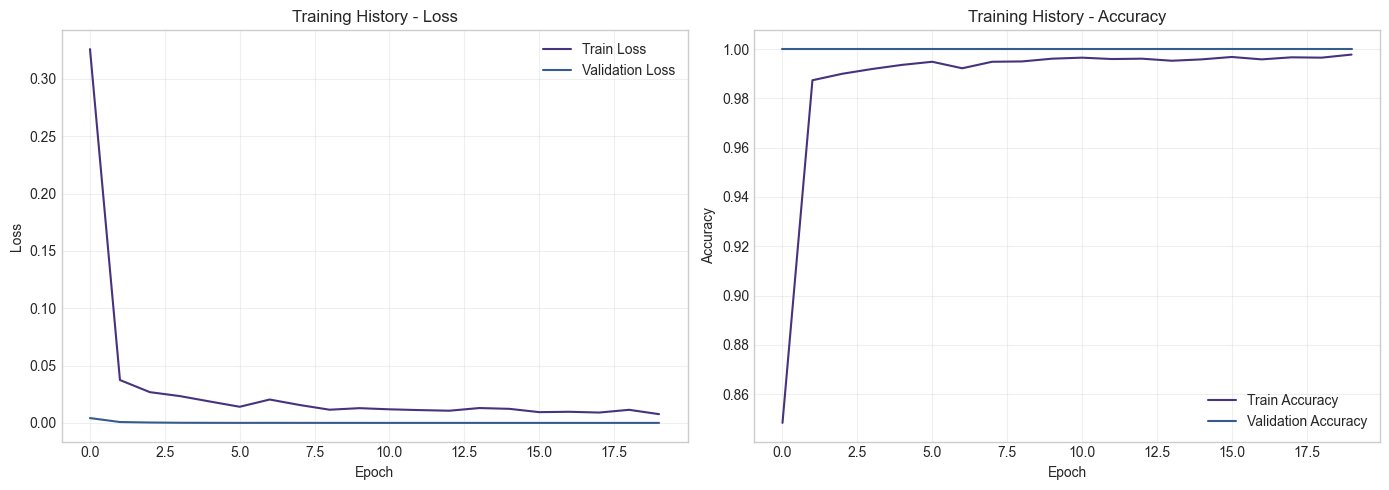

In [8]:
# LSTM Neural Network
print("="*60)
print("LSTM NEURAL NETWORK")
print("="*60)

start_time = time.time()

# Build LSTM model
def build_lstm_model(input_dim, embedding_dim=100, hidden_dim=128, dropout=0.5, learning_rate=0.001):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Reshape((1, input_dim)),
        layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout),
        layers.LSTM(hidden_dim // 2, dropout=dropout),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    )
    return model

# Create model
lstm_model = build_lstm_model(
    input_dim=X_train.shape[1],
    embedding_dim=100,
    hidden_dim=128,
    dropout=0.5,
    learning_rate=0.001
)

print(f"\n📊 Model Summary:")
lstm_model.summary()

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

# Train
history = lstm_model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Predictions
y_pred_proba_lstm = lstm_model.predict(X_test).flatten()
y_pred_lstm = (y_pred_proba_lstm >= 0.5).astype(int)

# Metrics
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm)
recall_lstm = recall_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm)
roc_auc_lstm = roc_auc_score(y_test, y_pred_proba_lstm)
train_time_lstm = time.time() - start_time

print(f"\n📊 Results:")
print(f"  • Accuracy:  {accuracy_lstm:.4f}")
print(f"  • Precision: {precision_lstm:.4f}")
print(f"  • Recall:    {recall_lstm:.4f}")
print(f"  • F1-score:  {f1_lstm:.4f}")
print(f"  • ROC-AUC:   {roc_auc_lstm:.4f}")
print(f"  • Train time: {train_time_lstm:.2f}s")

# Confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(f"\n📊 Confusion Matrix:")
print(f"              Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {cm_lstm[0,0]:6d}  {cm_lstm[0,1]:6d}")
print(f"       Pos    {cm_lstm[1,0]:6d}  {cm_lstm[1,1]:6d}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training History - Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(history.history['accuracy'], label='Train Accuracy')
ax.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training History - Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MODEL COMPARISON

📊 Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
0          Naive Bayes       1.0        1.0     1.0       1.0      1.0        0.062525
1  Logistic Regression       1.0        1.0     1.0       1.0      1.0        0.078127
2                  SVM       1.0        1.0     1.0       1.0      NaN        0.696257
3        Random Forest       1.0        1.0     1.0       1.0      1.0        0.395371
4              XGBoost       1.0        1.0     1.0       1.0      1.0        3.014192
5                 LSTM       1.0        1.0     1.0       1.0      1.0       19.899087

🏆 Best Model: Naive Bayes (F1-Score = 1.0000)


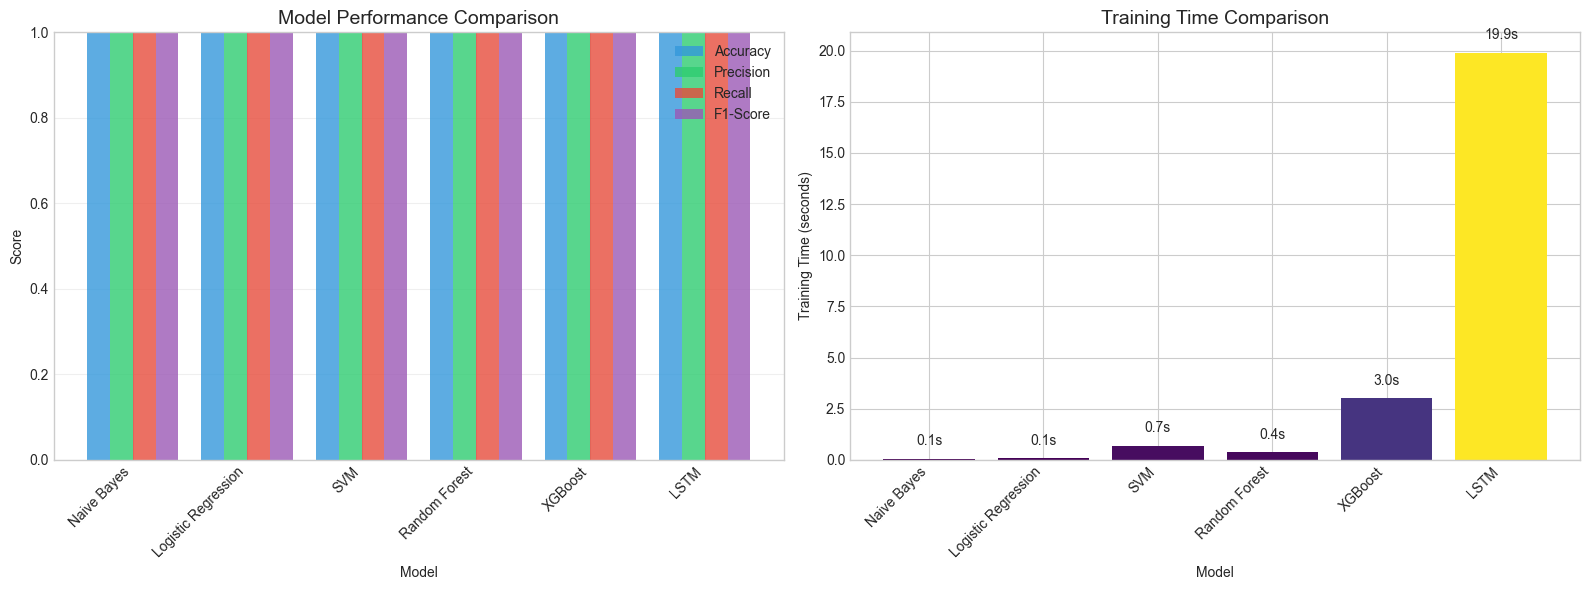

In [9]:
# Compare all models
print("="*60)
print("MODEL COMPARISON")
print("="*60)

# Collect results
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM', 'Random Forest', 'XGBoost', 'LSTM'],
    'Accuracy': [accuracy_nb, accuracy_lr, accuracy_svm, accuracy_rf, accuracy_xgb, accuracy_lstm],
    'Precision': [precision_nb, precision_lr, precision_svm, precision_rf, precision_xgb, precision_lstm],
    'Recall': [recall_nb, recall_lr, recall_svm, recall_rf, recall_xgb, recall_lstm],
    'F1-Score': [f1_nb, f1_lr, f1_svm, f1_rf, f1_xgb, f1_lstm],
    'ROC-AUC': [roc_auc_nb if 'roc_auc_nb' in locals() else None,
                roc_auc_lr, None, roc_auc_rf, roc_auc_xgb, roc_auc_lstm],
    'Train Time (s)': [train_time_nb, train_time_lr, train_time_svm, 
                       train_time_rf, train_time_xgb, train_time_lstm]
})

# Sort by F1-score
results = results.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n📊 Model Comparison Table:")
print(results.to_string())

# Find best model
best_model_idx = results['F1-Score'].idxmax()
best_model_name = results.loc[best_model_idx, 'Model']
best_f1 = results.loc[best_model_idx, 'F1-Score']

print(f"\n🏆 Best Model: {best_model_name} (F1-Score = {best_f1:.4f})")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
ax = axes[0]
x = np.arange(len(results))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results[metric], width, label=metric, color=color, alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Training time comparison
ax = axes[1]
colors_time = plt.cm.viridis(results['Train Time (s)'] / max(results['Train Time (s)']))
bars = ax.bar(range(len(results)), results['Train Time (s)'], color=colors_time)
ax.set_xlabel('Model')
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison', fontsize=14)
ax.set_xticks(range(len(results)))
ax.set_xticklabels(results['Model'], rotation=45, ha='right')

# Add value labels
for bar, time in zip(bars, results['Train Time (s)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
           f'{time:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

CONFUSION MATRICES


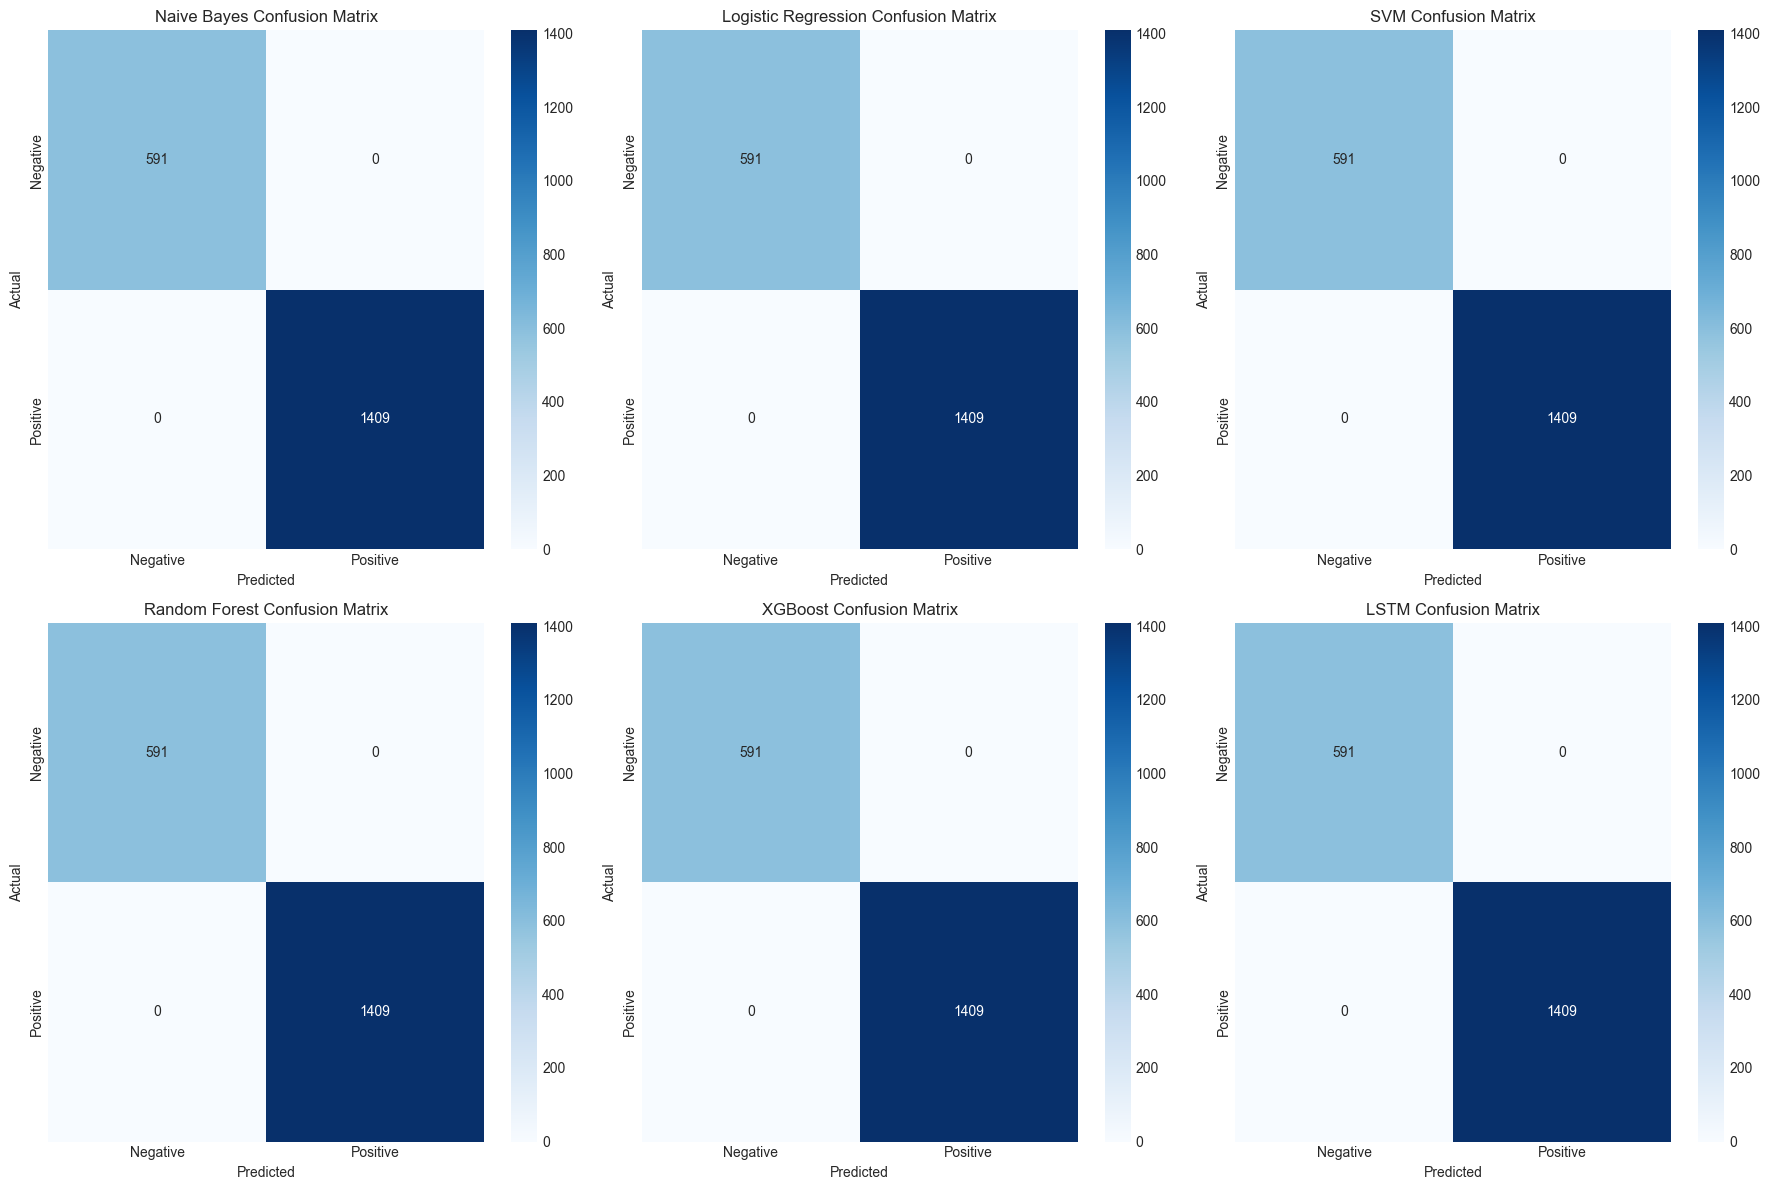

In [10]:
# Visualize confusion matrices
print("="*60)
print("CONFUSION MATRICES")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

models_cm = [
    ('Naive Bayes', cm_nb),
    ('Logistic Regression', cm_lr),
    ('SVM', cm_svm),
    ('Random Forest', cm_rf),
    ('XGBoost', cm_xgb),
    ('LSTM', cm_lstm)
]

for ax, (name, cm) in zip(axes.flat, models_cm):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

ROC CURVES


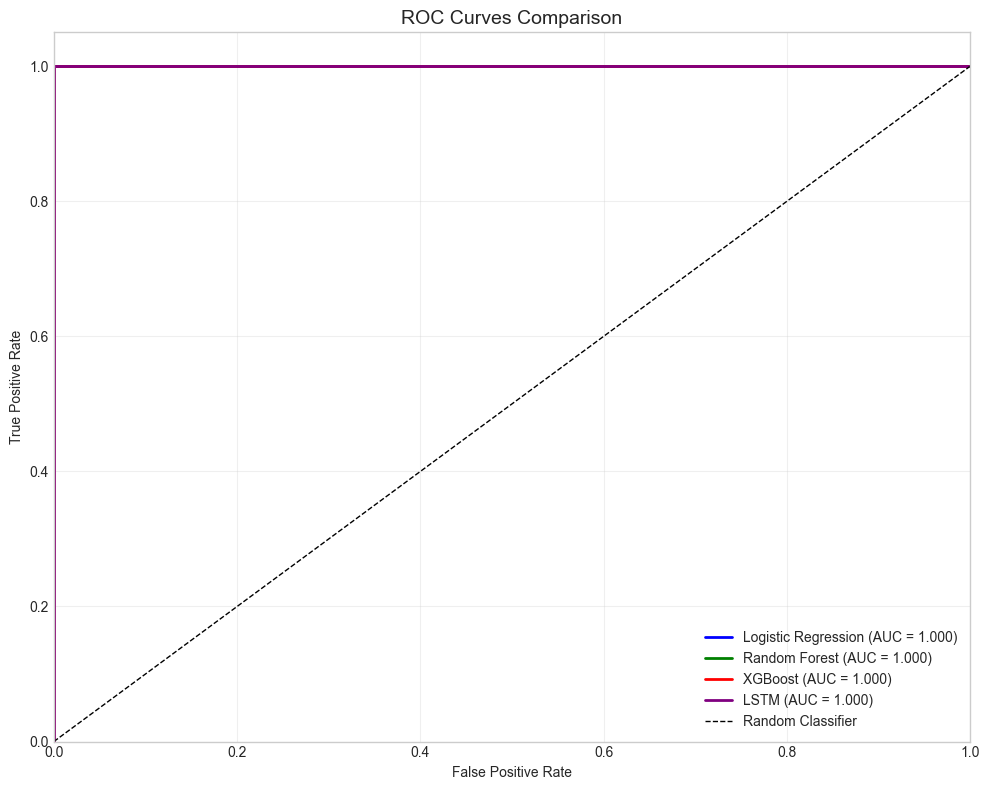

In [11]:
# Plot ROC curves
print("="*60)
print("ROC CURVES")
print("="*60)

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Models with probability predictions
roc_models = [
    ('Logistic Regression', y_test, y_pred_proba_lr),
    ('Random Forest', y_test, y_pred_proba_rf),
    ('XGBoost', y_test, y_pred_proba_xgb),
    ('LSTM', y_test, y_pred_proba_lstm)
]

colors = ['blue', 'green', 'red', 'purple']

for (name, y_true, y_score), color in zip(roc_models, colors):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Save best model
print("="*60)
print("SAVING BEST MODEL")
print("="*60)

os.makedirs('../outputs/models', exist_ok=True)

# Save based on best model
if best_model_name == 'Naive Bayes':
    joblib.dump(nb_model, '../outputs/models/best_model_nb.pkl')
elif best_model_name == 'Logistic Regression':
    joblib.dump(lr_model, '../outputs/models/best_model_lr.pkl')
elif best_model_name == 'SVM':
    joblib.dump(svm_model, '../outputs/models/best_model_svm.pkl')
elif best_model_name == 'Random Forest':
    joblib.dump(rf_model, '../outputs/models/best_model_rf.pkl')
elif best_model_name == 'XGBoost':
    joblib.dump(xgb_model, '../outputs/models/best_model_xgb.pkl')
elif best_model_name == 'LSTM':
    lstm_model.save('../outputs/models/best_model_lstm.h5')

print(f"✅ Saved best model: {best_model_name}")

# Save comparison results
results.to_csv('../outputs/tables/model_comparison.csv', index=False)
print(f"✅ Saved model comparison to ../outputs/tables/model_comparison.csv")

# Save classification report
from sklearn.metrics import classification_report

# Get predictions from best model
if best_model_name == 'Naive Bayes':
    y_pred_best = y_pred_nb
elif best_model_name == 'Logistic Regression':
    y_pred_best = y_pred_lr
elif best_model_name == 'SVM':
    y_pred_best = y_pred_svm
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
elif best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb
elif best_model_name == 'LSTM':
    y_pred_best = y_pred_lstm

report = classification_report(y_test, y_pred_best, target_names=['Negative', 'Positive'])
print(f"\n📊 Classification Report for {best_model_name}:")
print(report)

# Save report
with open('../outputs/reports/classification_report.txt', 'w') as f:
    f.write(f"Best Model: {best_model_name}\n")
    f.write("="*60 + "\n\n")
    f.write(report)

print(f"\n✅ Classification complete!")

SAVING BEST MODEL
✅ Saved best model: Naive Bayes
✅ Saved model comparison to ../outputs/tables/model_comparison.csv

📊 Classification Report for Naive Bayes:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       591
    Positive       1.00      1.00      1.00      1409

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


✅ Classification complete!
